In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth  # Do this in local & cloud setups
else:
    import torch; v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
    xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, "0.0.34")
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth
    !pip install --no-deps --upgrade "torchao>=0.16.0"


In [3]:
from unsloth import FastLanguageModel
from huggingface_hub import hf_hub_download
from peft import set_peft_model_state_dict
def load_adapter(repo):
   model,tokenizer=FastLanguageModel.from_pretrained(
        model_name="unsloth/Qwen3-0.6B",
        load_in_4bit=True,
        max_seq_length=2048,
   )
   model=FastLanguageModel.get_peft_model(
        model,
        r=16,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                        "gate_proj", "up_proj", "down_proj"],
        lora_alpha=32,
        lora_dropout=0,
        bias="none",
        use_gradient_checkpointing="unsloth",
        random_state=3407,
        use_rslora=False,
        loftq_config=None,
    )
   try:
        model_weights=hf_hub_download(
            repo_id=f"Srishtik/{repo}",
            filename="adapter_model.safetensors"
        )
   except:
        model_weights=hf_hub_download(
            repo_id=f"Srishtik/{repo}",
            filename="adapter_model.bin"
        )
   from safetensors.torch import load_file
   state_dict=load_file(model_weights)
   set_peft_model_state_dict(model,state_dict)
   return model
    

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [4]:
code_adapter=load_adapter("qwen3-trained-on-code-alpaca-18k")

==((====))==  Unsloth 2026.7.2: Fast Qwen3 patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Unsloth 2026.7.2 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


adapter_model.safetensors:   0%|          | 0.00/40.4M [00:00<?, ?B/s]

In [5]:
dolly_adapter=load_adapter("qwen3-trained-on-dolly-15k")

==((====))==  Unsloth 2026.7.2: Fast Qwen3 patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

adapter_model.safetensors:   0%|          | 0.00/40.4M [00:00<?, ?B/s]

In [6]:
metamath_adapter=load_adapter("qwen3-trained-on-metamath-15k")

==((====))==  Unsloth 2026.7.2: Fast Qwen3 patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

adapter_model.safetensors:   0%|          | 0.00/40.4M [00:00<?, ?B/s]

In [7]:
import torch

def extract_all_deltas(model):
    deltas = {}
    n_blocks = len(model.base_model.model.model.layers)
    
    for i in range(n_blocks):
        block = model.base_model.model.model.layers[i]
        
        for name, module in block.named_modules():
            if hasattr(module, 'lora_A') and hasattr(module, 'lora_B'):
                try:
                    A = module.lora_A.default.weight.detach().float()
                    B = module.lora_B.default.weight.detach().float()
                    scale = module.scaling.get("default", 1.0)
                    delta_W = scale * (B @ A)
                    deltas[f"layer_{i}.{name}"] = delta_W  # flat key
                except Exception as e:
                    print(f"Block {i} | {name} | error: {e}")
    
    return deltas
                
        

In [8]:
code_deltas=extract_all_deltas(code_adapter)

In [9]:
dolly_deltas=extract_all_deltas(dolly_adapter)

In [10]:
metamath_deltas=extract_all_deltas(metamath_adapter)

In [11]:
len(code_deltas)

196

In [12]:
for key,val in code_deltas.items():
    print(key)
    print(val)
    break

layer_0.self_attn.q_proj
tensor([[ 2.7147e-04, -2.0694e-04, -1.4640e-03,  ..., -1.5783e-03,
          9.2151e-04,  1.0666e-03],
        [-3.4017e-03, -2.2245e-03,  2.1250e-03,  ...,  1.6449e-03,
          9.4272e-04,  1.9657e-03],
        [-2.2020e-03,  2.4882e-04,  2.2900e-03,  ...,  3.6735e-03,
          3.8534e-04,  6.4499e-04],
        ...,
        [-2.3073e-04,  1.6338e-05,  1.5187e-03,  ..., -1.3157e-03,
         -9.3756e-05,  5.3751e-04],
        [ 1.7056e-04,  7.8255e-05, -5.0366e-04,  ..., -2.1793e-03,
         -1.4426e-04, -3.6126e-05],
        [-1.8755e-03, -1.0459e-03,  1.2384e-03,  ..., -1.7324e-03,
         -3.0190e-05,  1.1380e-03]], device='cuda:0')


In [13]:
# Check first item
key, val = list(code_deltas.items())[0]
print(key)
print(type(val))
print(val)

layer_0.self_attn.q_proj
<class 'torch.Tensor'>
tensor([[ 2.7147e-04, -2.0694e-04, -1.4640e-03,  ..., -1.5783e-03,
          9.2151e-04,  1.0666e-03],
        [-3.4017e-03, -2.2245e-03,  2.1250e-03,  ...,  1.6449e-03,
          9.4272e-04,  1.9657e-03],
        [-2.2020e-03,  2.4882e-04,  2.2900e-03,  ...,  3.6735e-03,
          3.8534e-04,  6.4499e-04],
        ...,
        [-2.3073e-04,  1.6338e-05,  1.5187e-03,  ..., -1.3157e-03,
         -9.3756e-05,  5.3751e-04],
        [ 1.7056e-04,  7.8255e-05, -5.0366e-04,  ..., -2.1793e-03,
         -1.4426e-04, -3.6126e-05],
        [-1.8755e-03, -1.0459e-03,  1.2384e-03,  ..., -1.7324e-03,
         -3.0190e-05,  1.1380e-03]], device='cuda:0')


In [14]:
!git clone https://github.com/SrishtikSekar/Lora_Adapter_Merging.git

Cloning into 'Lora_Adapter_Merging'...
remote: Enumerating objects: 175, done.
remote: Counting objects: 100% (175/175), done.
remote: Compressing objects: 100% (135/135), done.
remote: Total 175 (delta 97), reused 112 (delta 36), pack-reused 0 (from 0)
Receiving objects: 100% (175/175), 13.22 MiB | 29.61 MiB/s, done.
Resolving deltas: 100% (97/97), done.


In [15]:
!ls


huggingface_tokenizers_cache  Lora_Adapter_Merging  unsloth_compiled_cache


In [16]:
%cd Lora_Adapter_Merging

/kaggle/working/Lora_Adapter_Merging


In [17]:
!ls

docs			load_adapter.py      README.md
extract_lora_deltas.py	model_evaluation.py  train_adapter.py
frobenius_norm.py	notebooks	     train_adapter_using_responses.py


In [18]:
!git pull origin main

From https://github.com/SrishtikSekar/Lora_Adapter_Merging
 * branch            main       -> FETCH_HEAD
Already up to date.


# Model Comparision

## 1) Frobenius Norm

In [19]:
from frobenius_norm import frobenius_norm


In [20]:
def frobenius_norm(deltas):
    model_norms={}
    for layer_name,delta in deltas.items():
        model_norms[layer_name]=delta.norm(p="fro").item()
    import matplotlib.pyplot as plt

    layers=list(model_norms.keys())
    values=list(model_norms.values())

    plt.figure(figsize=(14,6))
    plt.plot(range(len(values)),values)
    plt.xticks(range(len(values)),layers,rotation=90)
    plt.ylabel("Frobenius Norm")
    plt.xlabel("Layer")
    plt.title("Layer wise LoRA Update Strength")
    plt.tight_layout()
    plt.show()


### 1.1) Reasoning model

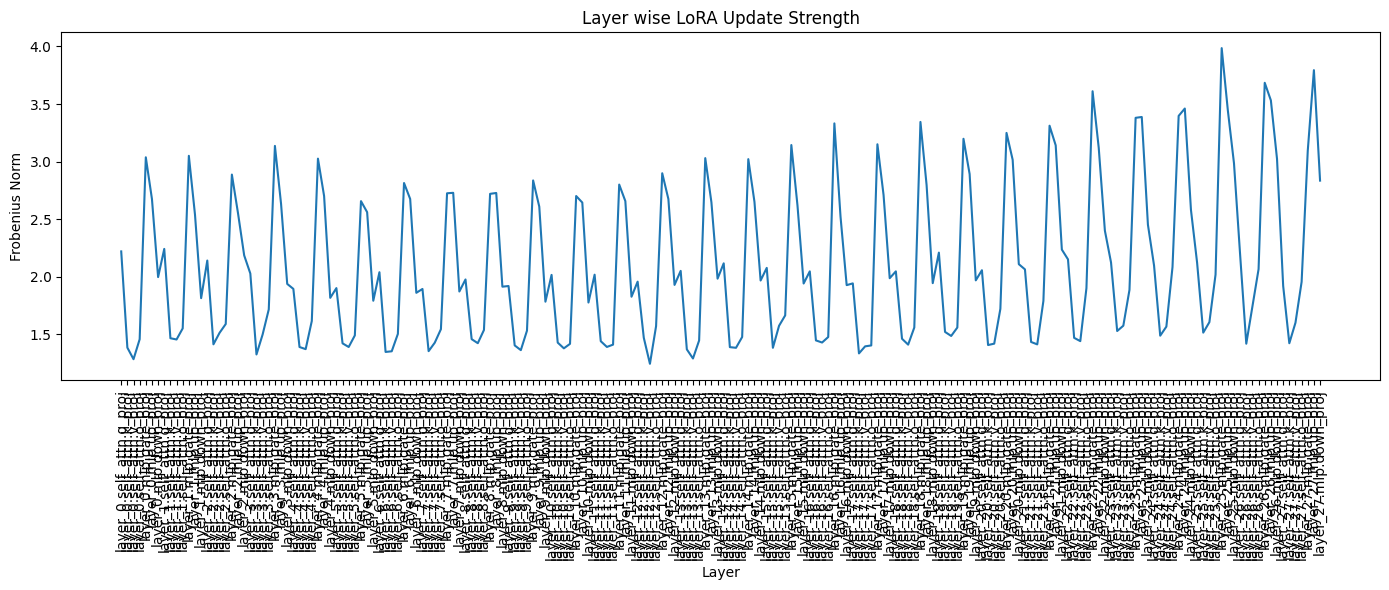

In [21]:
frobenius_norm(code_deltas)

### 1.2) Non-reasoning model

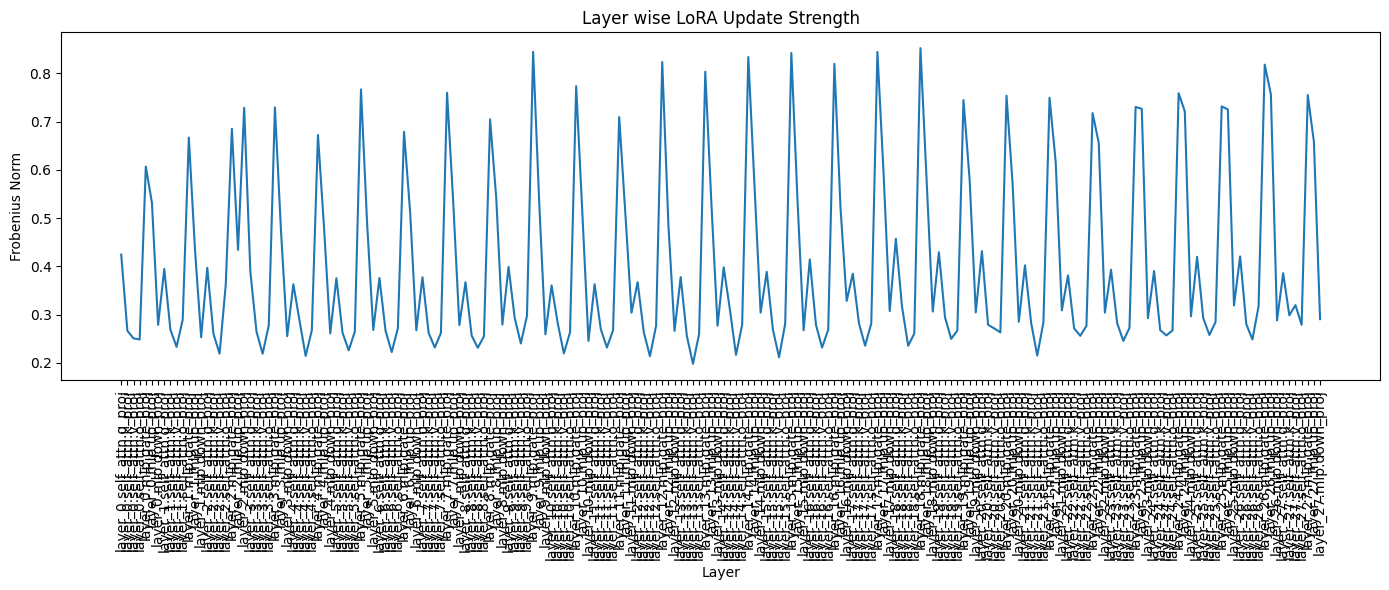

In [22]:
frobenius_norm(dolly_deltas)

### 1.3) AG-News model

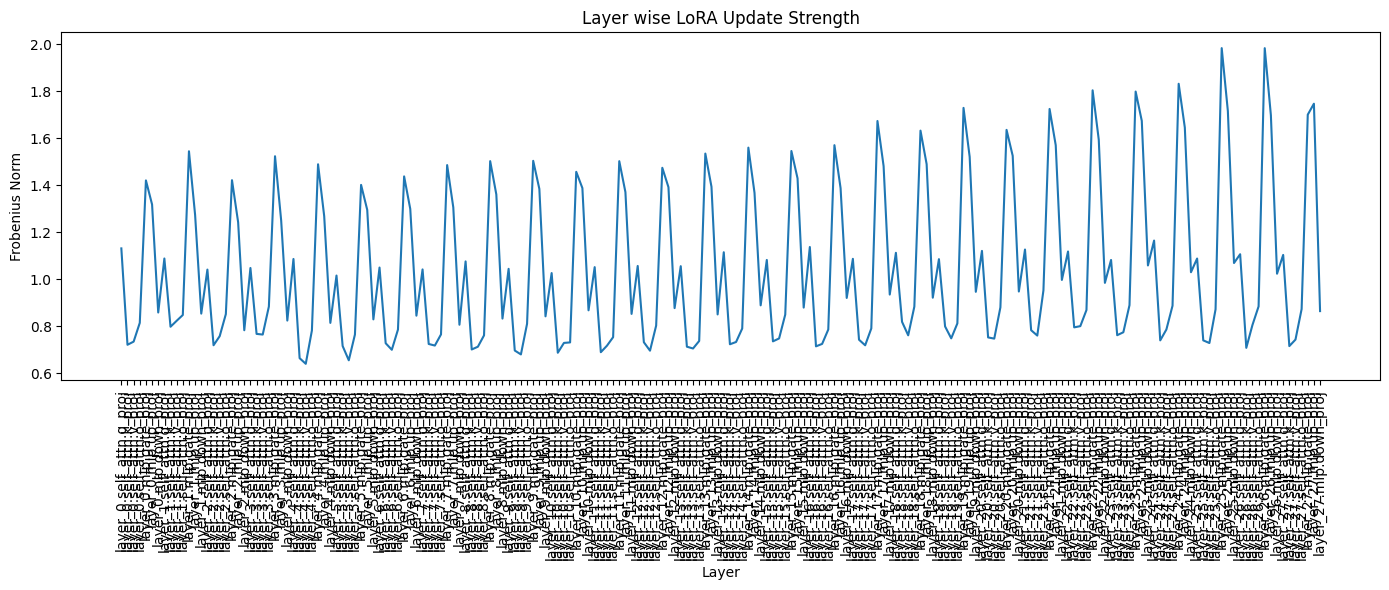

In [23]:
frobenius_norm(metamath_deltas)

## 2) Cosine Similarity

In [24]:
import torch
import pandas as pd

import torch
import pandas as pd


def true_cosine_similarity(delta1, delta2):

    v1 = delta1.flatten().to(torch.float64)
    v2 = delta2.flatten().to(torch.float64)

    dot_product = torch.dot(v1, v2)

    norm1 = torch.norm(v1)
    norm2 = torch.norm(v2)

    cosine = dot_product / (norm1 * norm2)

    return cosine.item()


def compute_all_layer_cosines(adapter1_deltas, adapter2_deltas):

    results = []

    common_layers = set(adapter1_deltas.keys()) & set(adapter2_deltas.keys())

    for layer_name in sorted(common_layers):

        delta1 = adapter1_deltas[layer_name]
        delta2 = adapter2_deltas[layer_name]

        cosine = true_cosine_similarity(delta1, delta2)

        results.append({
            "layer": layer_name,
            "cosine_similarity": cosine
        })

    return pd.DataFrame(results)


# Compute similarities
cosine_df1 = compute_all_layer_cosines(
    code_deltas,
    metamath_deltas,
)
cosine_df2=compute_all_layer_cosines(
    metamath_deltas,
    dolly_deltas,
)
cosine_df3=compute_all_layer_cosines(
    dolly_deltas,
    code_deltas
)



### 2.1) Comparision between non reasoning and reasoning

In [25]:
print(cosine_df1.to_string(index=False))

                    layer  cosine_similarity
    layer_0.mlp.down_proj           0.010844
    layer_0.mlp.gate_proj           0.011741
      layer_0.mlp.up_proj           0.027991
 layer_0.self_attn.k_proj           0.009656
 layer_0.self_attn.o_proj           0.011697
 layer_0.self_attn.q_proj           0.019022
 layer_0.self_attn.v_proj           0.035419
    layer_1.mlp.down_proj          -0.000817
    layer_1.mlp.gate_proj           0.016821
      layer_1.mlp.up_proj           0.042668
 layer_1.self_attn.k_proj           0.010057
 layer_1.self_attn.o_proj           0.007626
 layer_1.self_attn.q_proj           0.009674
 layer_1.self_attn.v_proj           0.086121
   layer_10.mlp.down_proj          -0.005647
   layer_10.mlp.gate_proj           0.002342
     layer_10.mlp.up_proj           0.026997
layer_10.self_attn.k_proj           0.054276
layer_10.self_attn.o_proj           0.004275
layer_10.self_attn.q_proj           0.033680
layer_10.self_attn.v_proj           0.059058
   layer_1

### 2.2) Comparision between reasoning and ag-news

In [26]:
print(cosine_df2.to_string(index=False))

                    layer  cosine_similarity
    layer_0.mlp.down_proj           0.056285
    layer_0.mlp.gate_proj           0.023634
      layer_0.mlp.up_proj           0.044466
 layer_0.self_attn.k_proj           0.038617
 layer_0.self_attn.o_proj           0.049552
 layer_0.self_attn.q_proj           0.039241
 layer_0.self_attn.v_proj           0.098485
    layer_1.mlp.down_proj           0.032264
    layer_1.mlp.gate_proj           0.027905
      layer_1.mlp.up_proj           0.048178
 layer_1.self_attn.k_proj           0.028465
 layer_1.self_attn.o_proj           0.028571
 layer_1.self_attn.q_proj           0.051125
 layer_1.self_attn.v_proj           0.107440
   layer_10.mlp.down_proj           0.030859
   layer_10.mlp.gate_proj           0.017388
     layer_10.mlp.up_proj           0.029759
layer_10.self_attn.k_proj           0.056098
layer_10.self_attn.o_proj           0.034754
layer_10.self_attn.q_proj           0.049176
layer_10.self_attn.v_proj           0.086598
   layer_1

### 2.3) Comparision between non reasoning and ag-news

In [27]:
print(cosine_df3.to_string(index=False))

                    layer  cosine_similarity
    layer_0.mlp.down_proj           0.010488
    layer_0.mlp.gate_proj           0.008622
      layer_0.mlp.up_proj           0.020584
 layer_0.self_attn.k_proj           0.010105
 layer_0.self_attn.o_proj           0.012735
 layer_0.self_attn.q_proj           0.016191
 layer_0.self_attn.v_proj           0.033333
    layer_1.mlp.down_proj           0.018983
    layer_1.mlp.gate_proj           0.005291
      layer_1.mlp.up_proj           0.033239
 layer_1.self_attn.k_proj           0.019911
 layer_1.self_attn.o_proj           0.018631
 layer_1.self_attn.q_proj           0.032255
 layer_1.self_attn.v_proj           0.078619
   layer_10.mlp.down_proj           0.021648
   layer_10.mlp.gate_proj           0.010439
     layer_10.mlp.up_proj           0.029186
layer_10.self_attn.k_proj           0.041635
layer_10.self_attn.o_proj           0.015261
layer_10.self_attn.q_proj           0.019363
layer_10.self_attn.v_proj           0.088460
   layer_1

## 3) Singular Values

In [28]:

import numpy as np
import torch
import matplotlib.pyplot as plt
def singular_values(deltas):
    layer_name=list(deltas.keys())[30]
    svals1 = torch.linalg.svdvals(deltas[layer_name]).cpu().numpy()
    plt.figure(figsize=(10, 5))
    plt.plot(svals1)
    plt.xlabel("Singular Value Index")
    plt.ylabel("Magnitude")
    plt.title(f"Singular Spectrum: {layer_name}")
    plt.show()


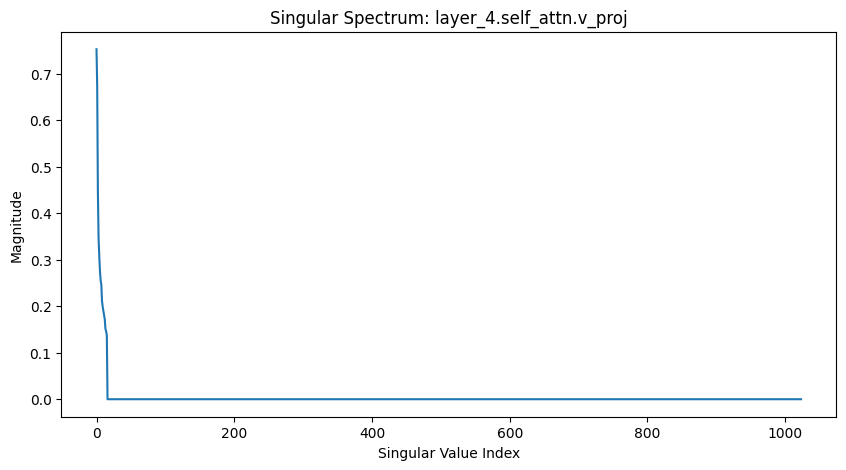

In [29]:
singular_values(code_deltas)

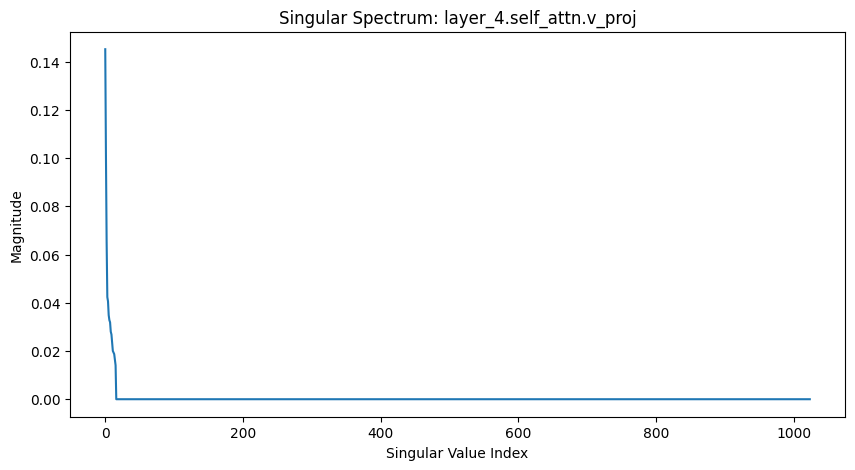

In [30]:
singular_values(dolly_deltas)

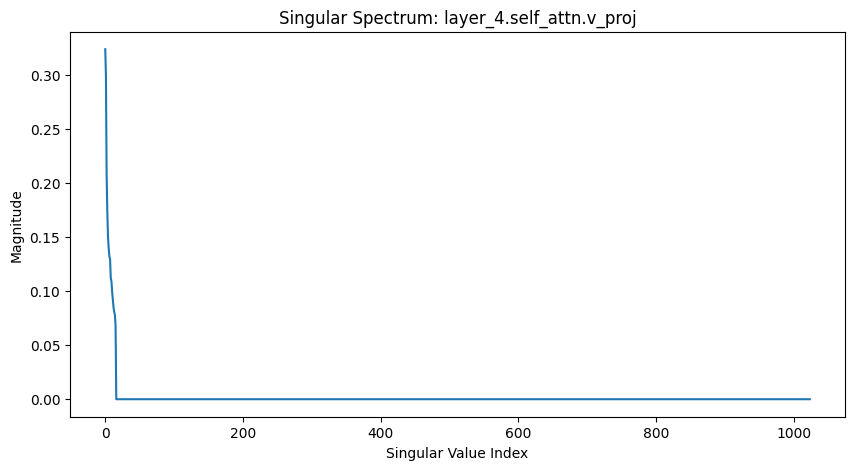

In [31]:
singular_values(metamath_deltas)